In [1]:
# ============================================================
# PHASE 13B — CELL 1
# Imports
# ============================================================

from pathlib import Path
import json
import re
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

print("Imports successful.")

Imports successful.


In [2]:
# ============================================================
# PHASE 13B — CELL 2
# Project root
# ============================================================

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:")
print(PROJECT_ROOT)

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project root does not exist: {PROJECT_ROOT}"
    )

Project root:
d:\downloads\misleading-health-infographic-detection


In [3]:
# ============================================================
# PHASE 13B — CELL 3
# Directories
# ============================================================

PHASE12_DIR = PROJECT_ROOT / "outputs" / "phase12"
PHASE13_DIR = PROJECT_ROOT / "outputs" / "phase13"
PHASE13B_DIR = PROJECT_ROOT / "outputs" / "phase13b"

CLAIMS_DIR = PHASE13B_DIR / "claims"
MANIFEST_DIR = PHASE13B_DIR / "manifests"
METRICS_DIR = PHASE13B_DIR / "metrics"
VIS_DIR = PHASE13B_DIR / "visualizations"
REPORTS_DIR = PHASE13B_DIR / "reports"

for directory in [
    PHASE13B_DIR,
    CLAIMS_DIR,
    MANIFEST_DIR,
    METRICS_DIR,
    VIS_DIR,
    REPORTS_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Phase 13B directories ready.")

Phase 13B directories ready.


In [4]:
# ============================================================
# PHASE 13B — CELL 4
# Load Phase 12 OCR manifest
# ============================================================

PHASE13_INPUT = (
    PHASE12_DIR
    / "manifests"
    / "phase13_claim_extraction_input.csv"
)

if not PHASE13_INPUT.exists():
    raise FileNotFoundError(
        f"""
Phase 13 input not found:

{PHASE13_INPUT}

Run Phase 12 first.
"""
    )

df = pd.read_csv(
    PHASE13_INPUT,
    encoding="utf-8-sig"
)

print("Input shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

display(df.head())

Input shape: (100, 10)
Columns:
['record_key', 'image_path', 'label', 'source', 'phase11_split', 'ocr_text', 'num_text_lines', 'ocr_char_count', 'ocr_word_count', 'ocr_quality']


,record_key,image_path,label,source,phase11_split,ocr_text,num_text_lines,ocr_char_count,ocr_word_count,ocr_quality
0,record_000000,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
1,record_000001,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
2,record_000002,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
3,record_000003,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
4,record_000004,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low


In [5]:
# ============================================================
# PHASE 13B — CELL 5
# Validate input
# ============================================================

REQUIRED_COLUMNS = [
    "record_key",
    "image_path",
    "label",
    "source",
    "phase11_split",
    "ocr_text",
    "num_text_lines",
    "ocr_char_count",
    "ocr_word_count",
    "ocr_quality"
]

missing_columns = [
    c for c in REQUIRED_COLUMNS
    if c not in df.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns:\n"
        + "\n".join(missing_columns)
    )

print("All required columns are present.")

print("Records:", len(df))

empty_ocr = (
    df["ocr_text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Empty OCR:", empty_ocr)

All required columns are present.
Records: 100
Empty OCR: 0


In [6]:
# ============================================================
# PHASE 13B — CELL 6
# OCR normalization
# ============================================================

def normalize_ocr_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # Normalize line endings
    text = re.sub(
        r"[\r\n]+",
        "\n",
        text
    )

    # Normalize repeated whitespace within lines
    lines = []

    for line in text.split("\n"):

        line = re.sub(
            r"\s+",
            " ",
            line
        ).strip()

        if line:
            lines.append(line)

    text = "\n".join(lines)

    # Normalize repeated punctuation
    text = re.sub(
        r"([!?.,;:])\1{2,}",
        r"\1",
        text
    )

    return text.strip()


df["clean_ocr_text"] = (
    df["ocr_text"]
    .apply(normalize_ocr_text)
)

print("OCR normalization complete.")

OCR normalization complete.


In [7]:
# ============================================================
# PHASE 13B — CELL 7
# Sentence and fragment generation
# ============================================================

def generate_text_fragments(text):

    if not text:
        return []

    lines = [
        line.strip()
        for line in str(text).split("\n")
        if line.strip()
    ]

    fragments = []

    for line in lines:

        # Remove common bullet prefixes
        line = re.sub(
            r"^[•●▪◦■□➤►\-–—]+\s*",
            "",
            line
        ).strip()

        if not line:
            continue

        # Sentence-level split
        parts = re.split(
            r"(?<=[.!?])\s+"
            r"|;\s+"
            r"|\|\s+",
            line
        )

        for part in parts:

            part = part.strip()

            if len(part) >= 5:
                fragments.append(part)

    # --------------------------------------------------------
    # Adjacent fragments
    # --------------------------------------------------------

    candidates = list(fragments)

    for i in range(len(fragments) - 1):

        first = fragments[i]
        second = fragments[i + 1]

        combined = f"{first} {second}"

        # Avoid excessively long combinations
        if len(combined) <= 240:

            candidates.append(combined)

    # Deduplicate while preserving order
    candidates = list(
        dict.fromkeys(candidates)
    )

    return candidates


df["text_fragments"] = (
    df["clean_ocr_text"]
    .apply(generate_text_fragments)
)

df["num_fragments"] = (
    df["text_fragments"]
    .apply(len)
)

print(
    "Total candidate fragments:",
    int(df["num_fragments"].sum())
)

display(
    df[
        [
            "record_key",
            "text_fragments"
        ]
    ].head()
)

Total candidate fragments: 350


,record_key,text_fragments
0,record_000000,[WebMD]
1,record_000001,[WebMD]
2,record_000002,[WebMD]
3,record_000003,[WebMD]
4,record_000004,[WebMD]


In [8]:
# ============================================================
# PHASE 13B — CELL 8
# Medical concepts
# ============================================================

HEALTH_CONCEPTS = {

    "disease_conditions": [
        "disease",
        "diseases",
        "diabetes",
        "cancer",
        "tumor",
        "tumour",
        "heart disease",
        "cardiovascular",
        "hypertension",
        "high blood pressure",
        "low blood pressure",
        "obesity",
        "asthma",
        "infection",
        "infections",
        "virus",
        "viral",
        "bacterial",
        "covid",
        "covid-19",
        "flu",
        "influenza",
        "arthritis"
    ],

    "symptoms": [
        "symptom",
        "symptoms",
        "pain",
        "fever",
        "fatigue",
        "headache",
        "nausea",
        "cough",
        "inflammation"
    ],

    "nutrition": [
        "food",
        "foods",
        "diet",
        "nutrition",
        "nutrient",
        "nutrients",
        "protein",
        "carbohydrate",
        "carbs",
        "fat",
        "fats",
        "sugar",
        "salt",
        "sodium",
        "calorie",
        "calories",
        "fiber",
        "fibre"
    ],

    "supplements": [
        "vitamin",
        "vitamins",
        "vitamin d",
        "vitamin c",
        "vitamin b",
        "iron",
        "calcium",
        "zinc",
        "magnesium",
        "supplement",
        "supplements"
    ],

    "medication_treatment": [
        "medicine",
        "medication",
        "drug",
        "drugs",
        "treatment",
        "therapy",
        "therapeutic",
        "vaccine",
        "vaccines",
        "vaccination",
        "dose",
        "doses",
        "dosage",
        "prescription"
    ],

    "lifestyle": [
        "exercise",
        "physical activity",
        "workout",
        "walking",
        "running",
        "sleep",
        "stress",
        "smoking",
        "alcohol",
        "weight loss",
        "weight gain",
        "obesity"
    ],

    "body_systems": [
        "heart",
        "brain",
        "blood",
        "blood sugar",
        "blood glucose",
        "immune system",
        "immunity",
        "lungs",
        "liver",
        "kidney",
        "kidneys",
        "gut",
        "digestive system"
    ],

    "medical_context": [
        "health",
        "healthy",
        "medical",
        "doctor",
        "patient",
        "patients",
        "clinical",
        "hospital",
        "healthcare",
        "public health"
    ]
}

ALL_HEALTH_TERMS = sorted(
    {
        term.lower()
        for terms in HEALTH_CONCEPTS.values()
        for term in terms
    },
    key=len,
    reverse=True
)

print(
    "Health concept groups:",
    len(HEALTH_CONCEPTS)
)

print(
    "Unique health terms:",
    len(ALL_HEALTH_TERMS)
)

Health concept groups: 8
Unique health terms: 109


In [9]:
# ============================================================
# PHASE 13B — CELL 9
# Claim cues
# ============================================================

CAUSAL_CUES = [
    "cause",
    "causes",
    "caused by",
    "lead to",
    "leads to",
    "result in",
    "results in",
    "results from"
]

EFFECT_CUES = [
    "increase",
    "increases",
    "increased",
    "decrease",
    "decreases",
    "decreased",
    "reduce",
    "reduces",
    "reduced",
    "lower",
    "lowers",
    "lowered",
    "raise",
    "raises",
    "boost",
    "boosts",
    "improve",
    "improves",
    "protect",
    "protects",
    "prevent",
    "prevents",
    "cure",
    "cures",
    "treat",
    "treats",
    "heal",
    "heals"
]

ASSOCIATION_CUES = [
    "associated with",
    "linked to",
    "related to",
    "connected to",
    "risk of",
    "increases the risk",
    "decreases the risk"
]

ASSERTION_CUES = [
    "is",
    "are",
    "was",
    "were",
    "can",
    "may",
    "might",
    "could",
    "has",
    "have",
    "contains",
    "contain",
    "helps",
    "help",
    "supports",
    "support",
    "shown to",
    "known to",
    "found to",
    "evidence suggests",
    "research shows",
    "studies show"
]

RECOMMENDATION_CUES = [
    "should",
    "must",
    "need to",
    "needs to",
    "recommended",
    "recommend",
    "avoid",
    "include",
    "eat",
    "take",
    "drink",
    "exercise",
    "consult",
    "talk to your doctor"
]

MODALITY_CUES = [
    "may",
    "might",
    "could",
    "possibly",
    "potentially",
    "likely",
    "unlikely"
]

CTA_PATTERNS = [
    r"^\s*visit\b",
    r"^\s*click\b",
    r"^\s*learn more\b",
    r"^\s*read more\b",
    r"^\s*find out\b",
    r"^\s*follow us\b",
    r"^\s*subscribe\b",
    r"^\s*download\b",
    r"information center",
    r"^\s*contact\b",
    r"^\s*www\.",
    r"^\s*https?://"
]

print("Claim cues loaded.")

Claim cues loaded.


In [10]:
# ============================================================
# PHASE 13B — CELL 10
# Helper functions
# ============================================================

def find_terms(text, terms):

    text_lower = text.lower()

    found = []

    for term in terms:

        pattern = (
            r"(?<!\w)"
            + re.escape(term)
            + r"(?!\w)"
        )

        if re.search(
            pattern,
            text_lower
        ):
            found.append(term)

    return list(dict.fromkeys(found))


def detect_health_terms(text):

    return find_terms(
        text,
        ALL_HEALTH_TERMS
    )


def detect_health_categories(text):

    text_lower = text.lower()

    categories = []

    for category, terms in HEALTH_CONCEPTS.items():

        for term in terms:

            if re.search(
                r"(?<!\w)"
                + re.escape(term.lower())
                + r"(?!\w)",
                text_lower
            ):
                categories.append(category)
                break

    return categories


def extract_quantitative_values(text):

    patterns = [
        r"\b\d+(?:\.\d+)?\s*%",
        r"\b\d+(?:\.\d+)?\s*(?:mg|mcg|g|kg|ml|l)\b",
        r"\b\d+(?:\.\d+)?\s*(?:days?|weeks?|months?|years?)\b",
        r"\b\d+(?:\.\d+)?\s*(?:doses?|vials?)\b"
    ]

    matches = []

    for pattern in patterns:

        matches.extend(
            re.findall(
                pattern,
                text,
                flags=re.IGNORECASE
            )
        )

    return list(
        dict.fromkeys(matches)
    )


def looks_like_cta(text):

    text_lower = text.lower().strip()

    return any(
        re.search(
            pattern,
            text_lower
        )
        for pattern in CTA_PATTERNS
    )


def looks_like_metadata(text):

    text_lower = text.lower().strip()

    exact_metadata = {
        "webmd",
        "health",
        "health tips",
        "medical news",
        "covid-19",
        "covid 19"
    }

    if text_lower in exact_metadata:
        return True

    if re.fullmatch(
        r"\d{4}",
        text_lower
    ):
        return True

    if re.fullmatch(
        r"\d+\s*(h|hours?)",
        text_lower
    ):
        return True

    return False


def looks_like_product_code(text):

    compact = re.sub(
        r"\s+",
        "",
        text
    )

    digit_count = sum(
        char.isdigit()
        for char in compact
    )

    alpha_count = sum(
        char.isalpha()
        for char in compact
    )

    health_terms = detect_health_terms(
        text
    )

    # Lots of numbers + very little normal language
    if (
        digit_count >= 5
        and alpha_count > 0
        and len(text.split()) <= 20
        and len(health_terms) <= 1
    ):
        return True

    # Vaccine/product lot-style strings
    if re.search(
        r"\b[A-Z]{2,}\d{2,}[A-Z0-9]*\b",
        text
    ) and len(text.split()) <= 15:
        return True

    return False


def looks_like_fragment(text):

    text = text.strip()

    if len(text.split()) < 3:
        return True

    # Ends with an obvious incomplete preposition
    if re.search(
        r"\b(of|to|for|with|and|or|the|a|an)$",
        text.lower()
    ):
        return True

    # Starts with a dangling punctuation/fragment
    if re.match(
        r"^[\"'(\-–—]",
        text
    ):
        stripped = text.lstrip(
            "\"'(-–— "
        )

        if len(stripped.split()) < 4:
            return True

    return False

In [11]:
# ============================================================
# PHASE 13B — CELL 11
# Claim candidate scoring
# ============================================================

def score_candidate(text):

    text = text.strip()
    text_lower = text.lower()

    health_terms = detect_health_terms(text)

    health_categories = detect_health_categories(text)

    causal_hits = find_terms(
        text,
        CAUSAL_CUES
    )

    effect_hits = find_terms(
        text,
        EFFECT_CUES
    )

    association_hits = find_terms(
        text,
        ASSOCIATION_CUES
    )

    assertion_hits = find_terms(
        text,
        ASSERTION_CUES
    )

    recommendation_hits = find_terms(
        text,
        RECOMMENDATION_CUES
    )

    modality_hits = find_terms(
        text,
        MODALITY_CUES
    )

    quantitative_values = (
        extract_quantitative_values(text)
    )

    score = 0

    # --------------------------------------------------------
    # Positive evidence
    # --------------------------------------------------------

    if health_terms:
        score += 2

    if len(health_terms) >= 2:
        score += 1

    if causal_hits:
        score += 3

    if effect_hits:
        score += 2

    if association_hits:
        score += 3

    if assertion_hits:
        score += 1

    if recommendation_hits:
        score += 3

    if modality_hits:
        score += 1

    if (
        quantitative_values
        and health_terms
    ):
        score += 2

    # Longer coherent statement
    if len(text.split()) >= 6:
        score += 1

    # --------------------------------------------------------
    # Negative evidence
    # --------------------------------------------------------

    if looks_like_metadata(text):
        score -= 8

    if looks_like_cta(text):
        score -= 6

    if looks_like_product_code(text):
        score -= 4

    if looks_like_fragment(text):
        score -= 2

    return {
        "score": score,
        "health_terms": health_terms,
        "health_categories": health_categories,
        "causal_hits": causal_hits,
        "effect_hits": effect_hits,
        "association_hits": association_hits,
        "assertion_hits": assertion_hits,
        "recommendation_hits": recommendation_hits,
        "modality_hits": modality_hits,
        "quantitative_values": quantitative_values,
        "is_metadata": looks_like_metadata(text),
        "is_cta": looks_like_cta(text),
        "is_product_code": looks_like_product_code(text),
        "is_fragment": looks_like_fragment(text)
    }

In [12]:
# ============================================================
# PHASE 13B — CELL 12
# Generate and score candidates
# ============================================================

candidate_records = []

for _, row in df.iterrows():

    for index, text in enumerate(
        row["text_fragments"]
    ):

        analysis = score_candidate(text)

        # ----------------------------------------------------
        # Strong claim evidence
        # ----------------------------------------------------

        has_relationship = bool(
            analysis["causal_hits"]
            or analysis["effect_hits"]
            or analysis["association_hits"]
        )

        has_recommendation = bool(
            analysis["recommendation_hits"]
        )

        has_quantitative_claim = bool(
            analysis["quantitative_values"]
            and analysis["health_terms"]
        )

        has_health_assertion = bool(
            analysis["health_terms"]
            and analysis["assertion_hits"]
        )

        strong_pattern = (
            has_relationship
            or has_recommendation
            or has_quantitative_claim
            or has_health_assertion
        )

        accepted = (
            analysis["score"] >= 4
            and strong_pattern
            and not analysis["is_metadata"]
            and not analysis["is_cta"]
            and not analysis["is_product_code"]
        )

        candidate_records.append({

            "record_key":
                row["record_key"],

            "image_path":
                row["image_path"],

            "label":
                row["label"],

            "source":
                row["source"],

            "phase11_split":
                row["phase11_split"],

            "fragment_index":
                index,

            "claim_text":
                text,

            "candidate_score":
                analysis["score"],

            "health_terms":
                analysis["health_terms"],

            "health_categories":
                analysis["health_categories"],

            "causal_cues":
                analysis["causal_hits"],

            "effect_cues":
                analysis["effect_hits"],

            "association_cues":
                analysis["association_hits"],

            "assertion_cues":
                analysis["assertion_hits"],

            "recommendation_cues":
                analysis["recommendation_hits"],

            "modality_cues":
                analysis["modality_hits"],

            "quantitative_values":
                analysis["quantitative_values"],

            "is_metadata":
                analysis["is_metadata"],

            "is_cta":
                analysis["is_cta"],

            "is_product_code":
                analysis["is_product_code"],

            "is_fragment":
                analysis["is_fragment"],

            "accepted":
                accepted
        })


candidate_audit = pd.DataFrame(
    candidate_records
)

print(
    "Total candidate fragments:",
    len(candidate_audit)
)

print(
    "Accepted claim candidates:",
    int(candidate_audit["accepted"].sum())
)

print(
    "Rejected candidates:",
    int((~candidate_audit["accepted"]).sum())
)

Total candidate fragments: 350
Accepted claim candidates: 14
Rejected candidates: 336


In [13]:
# ============================================================
# PHASE 13B — CELL 13
# Inspect accepted candidates
# ============================================================

accepted = candidate_audit[
    candidate_audit["accepted"]
].copy()

print(
    "Accepted candidates:",
    len(accepted)
)

display(
    accepted[
        [
            "record_key",
            "claim_text",
            "candidate_score",
            "health_terms",
            "causal_cues",
            "effect_cues",
            "association_cues",
            "recommendation_cues",
            "quantitative_values"
        ]
    ]
    .sort_values(
        ["candidate_score", "record_key"],
        ascending=[False, True]
    )
    .head(100)
)

Accepted candidates: 14


,record_key,claim_text,candidate_score,health_terms,causal_cues,effect_cues,association_cues,recommendation_cues,quantitative_values
87,record_000062,Each vial contains 5 doses of 0.5 mL Janssen C...,7,"[covid-19, vaccine, doses, covid]",[],[],[],[],"[0.5 mL, 5 doses]"
126,record_000073,COVID-19 Vaccine contains 6 doses of 0.3 mL,7,"[covid-19, vaccine, doses, covid]",[],[],[],[],"[0.3 mL, 6 doses]"
265,record_000136,Each vial contains 5 doses of 0.5 mL Janssen C...,7,"[covid-19, vaccine, doses, covid]",[],[],[],[],"[0.5 mL, 5 doses]"
304,record_000147,COVID-19 Vaccine contains 6 doses of 0.3 mL,7,"[covid-19, vaccine, doses, covid]",[],[],[],[],"[0.3 mL, 6 doses]"
75,record_000062,Each vial contains 5 doses of 0.5 mL,6,[doses],[],[],[],[],"[0.5 mL, 5 doses]"
86,record_000062,No Preservative Each vial contains 5 doses of ...,6,[doses],[],[],[],[],"[0.5 mL, 5 doses]"
114,record_000073,contains 6 doses of 0.3 mL,6,[doses],[],[],[],[],"[0.3 mL, 6 doses]"
253,record_000136,Each vial contains 5 doses of 0.5 mL,6,[doses],[],[],[],[],"[0.5 mL, 5 doses]"
264,record_000136,No Preservative Each vial contains 5 doses of ...,6,[doses],[],[],[],[],"[0.5 mL, 5 doses]"
292,record_000147,contains 6 doses of 0.3 mL,6,[doses],[],[],[],[],"[0.3 mL, 6 doses]"


In [14]:
# ============================================================
# PHASE 13B — CELL 14
# Build refined claim dataframe
# ============================================================

refined_claims = accepted.copy()

# Clean surrounding quotes/punctuation
refined_claims["claim_text"] = (
    refined_claims["claim_text"]
    .astype(str)
    .str.strip()
    .str.strip("\"'")
    .str.strip()
)

# Normalize whitespace
refined_claims["claim_text"] = (
    refined_claims["claim_text"]
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

print(
    "Refined claims before deduplication:",
    len(refined_claims)
)

Refined claims before deduplication: 14


In [15]:
# ============================================================
# PHASE 13B — CELL 15
# Claim type classification
# ============================================================

def classify_claim_type(row):

    text = row["claim_text"].lower()

    # Causal
    if (
        row["causal_cues"]
        or re.search(
            r"\b(cause|causes|caused|lead to|leads to|result in|results in)\b",
            text
        )
    ):
        return "causal"

    # Preventive
    if re.search(
        r"\b(prevent|prevents|prevention|protect|protects)\b",
        text
    ):
        return "preventive"

    # Therapeutic
    if re.search(
        r"\b(treat|treats|treatment|cure|cures|therapy|therapeutic|heal|heals)\b",
        text
    ):
        return "therapeutic"

    # Risk / association
    if (
        row["association_cues"]
        or re.search(
            r"\b(risk|associated|linked|related|connected)\b",
            text
        )
    ):
        return "risk_association"

    # Recommendation
    if row["recommendation_cues"]:
        return "recommendation"

    # Quantitative
    if (
        row["quantitative_values"]
        and row["health_terms"]
    ):
        return "quantitative"

    # General health
    if (
        row["health_terms"]
        and row["assertion_cues"]
    ):
        return "general_health"

    return "unknown"


refined_claims["claim_type"] = (
    refined_claims
    .apply(
        classify_claim_type,
        axis=1
    )
)

print(
    refined_claims["claim_type"]
    .value_counts()
)

claim_type
quantitative      10
unknown            2
general_health     2
Name: count, dtype: int64


In [16]:
# ============================================================
# PHASE 13B — CELL 16
# Topic extraction
# ============================================================

def extract_topics(text, categories):

    text_lower = text.lower()

    topics = list(categories)

    mappings = {

        "diabetes": [
            "diabetes",
            "blood sugar",
            "glucose",
            "insulin"
        ],

        "cardiovascular": [
            "heart",
            "blood pressure",
            "hypertension",
            "cholesterol",
            "cardiovascular"
        ],

        "immunity_infection": [
            "immune",
            "immunity",
            "vaccine",
            "vaccination",
            "infection",
            "virus"
        ],

        "vitamins_minerals": [
            "vitamin",
            "iron",
            "calcium",
            "zinc",
            "magnesium"
        ],

        "weight": [
            "weight",
            "obesity",
            "overweight"
        ],

        "exercise": [
            "exercise",
            "physical activity",
            "workout",
            "walking",
            "running"
        ],

        "sleep": [
            "sleep",
            "insomnia"
        ],

        "cancer": [
            "cancer",
            "tumor",
            "tumour"
        ]
    }

    for topic, terms in mappings.items():

        if any(
            term in text_lower
            for term in terms
        ):
            topics.append(topic)

    topics = list(
        dict.fromkeys(topics)
    )

    if not topics:
        topics = ["other"]

    return topics


refined_claims["topics"] = refined_claims.apply(
    lambda row: extract_topics(
        row["claim_text"],
        row["health_categories"]
    ),
    axis=1
)

display(
    refined_claims[
        [
            "claim_text",
            "claim_type",
            "topics"
        ]
    ].head(50)
)

,claim_text,claim_type,topics
64,"The purpose of this campaign is, ""to help redu...",unknown,[other]
67,"get the vaccine."" That is a direct quote",general_health,"[medication_treatment, immunity_infection]"
75,Each vial contains 5 doses of 0.5 mL,quantitative,[medication_treatment]
86,No Preservative Each vial contains 5 doses of ...,quantitative,[medication_treatment]
87,Each vial contains 5 doses of 0.5 mL Janssen C...,quantitative,"[disease_conditions, medication_treatment, imm..."
114,contains 6 doses of 0.3 mL,quantitative,[medication_treatment]
126,COVID-19 Vaccine contains 6 doses of 0.3 mL,quantitative,"[disease_conditions, medication_treatment, imm..."
239,"The purpose of this campaign is, ""to help redu...",unknown,[other]
242,"get the vaccine."" That is a direct quote",general_health,"[medication_treatment, immunity_infection]"
253,Each vial contains 5 doses of 0.5 mL,quantitative,[medication_treatment]


In [17]:
# ============================================================
# PHASE 13B — CELL 17
# Deduplicate claims
# ============================================================

before_dedup = len(refined_claims)

refined_claims["normalized_claim"] = (
    refined_claims["claim_text"]
    .str.lower()
    .str.replace(
        r"[^a-z0-9%.\s]",
        " ",
        regex=True
    )
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

refined_claims = (
    refined_claims
    .drop_duplicates(
        subset=[
            "record_key",
            "normalized_claim"
        ]
    )
    .copy()
)

refined_claims = (
    refined_claims
    .reset_index(drop=True)
)

print(
    "Claims before deduplication:",
    before_dedup
)

print(
    "Claims after deduplication:",
    len(refined_claims)
)

Claims before deduplication: 14
Claims after deduplication: 14


In [18]:
# ============================================================
# PHASE 13B — CELL 18
# Claim IDs
# ============================================================

refined_claims["claim_id"] = [
    f"claim13b_{i:06d}"
    for i in range(
        len(refined_claims)
    )
]

print(
    "Final refined claims:",
    len(refined_claims)
)

print(
    "Records represented:",
    refined_claims["record_key"].nunique()
    if len(refined_claims)
    else 0
)

display(
    refined_claims[
        [
            "claim_id",
            "record_key",
            "claim_text",
            "candidate_score",
            "claim_type",
            "topics"
        ]
    ]
)

Final refined claims: 14
Records represented: 6


,claim_id,record_key,claim_text,candidate_score,claim_type,topics
0,claim13b_000000,record_000050,"The purpose of this campaign is, ""to help redu...",4,unknown,[other]
1,claim13b_000001,record_000050,"get the vaccine."" That is a direct quote",4,general_health,"[medication_treatment, immunity_infection]"
2,claim13b_000002,record_000062,Each vial contains 5 doses of 0.5 mL,6,quantitative,[medication_treatment]
3,claim13b_000003,record_000062,No Preservative Each vial contains 5 doses of ...,6,quantitative,[medication_treatment]
4,claim13b_000004,record_000062,Each vial contains 5 doses of 0.5 mL Janssen C...,7,quantitative,"[disease_conditions, medication_treatment, imm..."
5,claim13b_000005,record_000073,contains 6 doses of 0.3 mL,6,quantitative,[medication_treatment]
6,claim13b_000006,record_000073,COVID-19 Vaccine contains 6 doses of 0.3 mL,7,quantitative,"[disease_conditions, medication_treatment, imm..."
7,claim13b_000007,record_000121,"The purpose of this campaign is, ""to help redu...",4,unknown,[other]
8,claim13b_000008,record_000121,"get the vaccine."" That is a direct quote",4,general_health,"[medication_treatment, immunity_infection]"
9,claim13b_000009,record_000136,Each vial contains 5 doses of 0.5 mL,6,quantitative,[medication_treatment]


In [19]:
# ============================================================
# PHASE 13B — CELL 19
# Save candidate audit
# ============================================================

CANDIDATE_AUDIT_PATH = (
    MANIFEST_DIR /
    "phase13b_candidate_audit.csv"
)

candidate_audit.to_csv(
    CANDIDATE_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Candidate audit saved:"
)

print(
    CANDIDATE_AUDIT_PATH
)

Candidate audit saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase13b_candidate_audit.csv


In [20]:
# ============================================================
# PHASE 13B — CELL 20
# Save claim manifest
# ============================================================

CLAIM_MANIFEST_PATH = (
    MANIFEST_DIR /
    "phase13b_claims_manifest.csv"
)

refined_claims.to_csv(
    CLAIM_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Claim manifest saved:"
)

print(
    CLAIM_MANIFEST_PATH
)

Claim manifest saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase13b_claims_manifest.csv


In [21]:
# ============================================================
# PHASE 13B — CELL 21
# JSON-safe conversion
# ============================================================

def json_safe(value):

    if value is None:
        return None

    if isinstance(
        value,
        Path
    ):
        return str(value)

    if isinstance(
        value,
        np.ndarray
    ):
        return [
            json_safe(x)
            for x in value.tolist()
        ]

    if isinstance(
        value,
        np.generic
    ):
        return json_safe(
            value.item()
        )

    if isinstance(
        value,
        dict
    ):
        return {
            str(k): json_safe(v)
            for k, v in value.items()
        }

    if isinstance(
        value,
        (list, tuple, set)
    ):
        return [
            json_safe(x)
            for x in value
        ]

    if isinstance(
        value,
        float
    ):
        if math.isnan(value) or math.isinf(value):
            return None

    if pd.isna(value):
        return None

    return value

In [22]:
# ============================================================
# PHASE 13B — CELL 22
# Save claims JSONL
# ============================================================

CLAIMS_JSONL_PATH = (
    MANIFEST_DIR /
    "phase13b_claims.jsonl"
)

with open(
    CLAIMS_JSONL_PATH,
    "w",
    encoding="utf-8"
) as f:

    for record in refined_claims.to_dict(
        orient="records"
    ):

        f.write(
            json.dumps(
                json_safe(record),
                ensure_ascii=False
            )
            + "\n"
        )

print(
    "Claims JSONL saved:"
)

print(
    CLAIMS_JSONL_PATH
)

Claims JSONL saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase13b_claims.jsonl


In [23]:
# ============================================================
# PHASE 13B — CELL 23
# Record-level JSONs
# ============================================================

# Delete stale Phase 13B record JSONs
for old_file in CLAIMS_DIR.glob("record_*.json"):
    old_file.unlink()

saved_records = 0

claims_by_record = {
    key: group
    for key, group in refined_claims.groupby(
        "record_key"
    )
}

for _, source_row in df.iterrows():

    record_key = source_row["record_key"]

    group = claims_by_record.get(
        record_key,
        pd.DataFrame()
    )

    claims = []

    if len(group):

        for _, row in group.iterrows():

            claims.append({

                "claim_id":
                    row["claim_id"],

                "claim_text":
                    row["claim_text"],

                "claim_type":
                    row["claim_type"],

                "topics":
                    row["topics"],

                "candidate_score":
                    row["candidate_score"],

                "health_terms":
                    row["health_terms"],

                "quantitative_values":
                    row["quantitative_values"]
            })

    record_object = {

        "record_key":
            record_key,

        "image_path":
            source_row["image_path"],

        "label":
            source_row["label"],

        "source":
            source_row["source"],

        "phase11_split":
            source_row["phase11_split"],

        "ocr_quality":
            source_row["ocr_quality"],

        "ocr_text":
            source_row["clean_ocr_text"],

        "num_claims":
            len(claims),

        "claims":
            claims
    }

    output_path = (
        CLAIMS_DIR /
        f"{record_key}.json"
    )

    with open(
        output_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            json_safe(record_object),
            f,
            indent=2,
            ensure_ascii=False
        )

    saved_records += 1

print(
    "Record-level JSON files saved:",
    saved_records
)

Record-level JSON files saved: 100


In [24]:
# ============================================================
# PHASE 13B — CELL 24
# Claims per record
# ============================================================

claims_per_record = (
    refined_claims
    .groupby("record_key")
    .size()
    .rename("num_claims")
    .reset_index()
)

record_claim_counts = df[
    [
        "record_key",
        "source",
        "label"
    ]
].merge(
    claims_per_record,
    on="record_key",
    how="left"
)

record_claim_counts["num_claims"] = (
    record_claim_counts["num_claims"]
    .fillna(0)
    .astype(int)
)

print(
    "Records:",
    len(record_claim_counts)
)

print(
    "Records with claims:",
    int(
        (
            record_claim_counts["num_claims"] > 0
        ).sum()
    )
)

print(
    "Records without claims:",
    int(
        (
            record_claim_counts["num_claims"] == 0
        ).sum()
    )
)

display(
    record_claim_counts[
        "num_claims"
    ].describe()
)

Records: 100
Records with claims: 6
Records without claims: 94


count    100.00000
mean       0.14000
std        0.56889
min        0.00000
25%        0.00000
50%        0.00000
75%        0.00000
max        3.00000
Name: num_claims, dtype: float64

In [25]:
# ============================================================
# PHASE 13B — CELL 25
# Claim type statistics
# ============================================================

claim_type_stats = (
    refined_claims["claim_type"]
    .value_counts()
    .rename_axis("claim_type")
    .reset_index(name="count")
)

display(
    claim_type_stats
)

TYPE_STATS_PATH = (
    METRICS_DIR /
    "claim_type_stats.csv"
)

claim_type_stats.to_csv(
    TYPE_STATS_PATH,
    index=False,
    encoding="utf-8-sig"
)

,claim_type,count
0,quantitative,10
1,unknown,2
2,general_health,2


In [26]:
# ============================================================
# PHASE 13B — CELL 26
# Source and label statistics
# ============================================================

source_stats = (
    refined_claims
    .groupby("source")
    .agg(
        total_claims=(
            "claim_id",
            "count"
        ),
        records_with_claims=(
            "record_key",
            "nunique"
        )
    )
    .reset_index()
)

source_stats["claims_per_record"] = (
    source_stats["total_claims"]
    /
    source_stats["records_with_claims"]
    .replace(0, np.nan)
)

label_stats = (
    refined_claims
    .groupby("label")
    .agg(
        total_claims=(
            "claim_id",
            "count"
        ),
        records_with_claims=(
            "record_key",
            "nunique"
        )
    )
    .reset_index()
)

label_stats["claims_per_record"] = (
    label_stats["total_claims"]
    /
    label_stats["records_with_claims"]
    .replace(0, np.nan)
)

display(source_stats)
display(label_stats)

SOURCE_STATS_PATH = (
    METRICS_DIR /
    "source_wise_claim_stats.csv"
)

LABEL_STATS_PATH = (
    METRICS_DIR /
    "label_wise_claim_stats.csv"
)

source_stats.to_csv(
    SOURCE_STATS_PATH,
    index=False,
    encoding="utf-8-sig"
)

label_stats.to_csv(
    LABEL_STATS_PATH,
    index=False,
    encoding="utf-8-sig"
)

,source,total_claims,records_with_claims,claims_per_record
0,MMCoVar,7,3,2.333333
1,ReCOVery,7,3,2.333333


,label,total_claims,records_with_claims,claims_per_record
0,0,7,3,2.333333
1,1,7,3,2.333333


In [27]:
# ============================================================
# PHASE 13B — CELL 27
# Baseline comparison
# ============================================================

BASELINE_MANIFEST = (
    PHASE13_DIR
    / "manifests"
    / "phase13_claims_manifest.csv"
)

if not BASELINE_MANIFEST.exists():

    raise FileNotFoundError(
        f"""
Phase 13 baseline manifest not found:

{BASELINE_MANIFEST}

Run notebook 09_phase13_medical_claim_extraction.ipynb
before finalizing Phase 13B.
"""
    )

baseline_claims = pd.read_csv(
    BASELINE_MANIFEST,
    encoding="utf-8-sig"
)

baseline_count = len(
    baseline_claims
)

baseline_records = (
    baseline_claims["record_key"]
    .nunique()
)

refined_count = len(
    refined_claims
)

refined_records = (
    refined_claims["record_key"]
    .nunique()
    if refined_count
    else 0
)

comparison = pd.DataFrame([

    {
        "pipeline": "Phase 13 baseline",
        "total_claims": baseline_count,
        "records_with_claims": baseline_records
    },

    {
        "pipeline": "Phase 13B refined",
        "total_claims": refined_count,
        "records_with_claims": refined_records
    }
])

display(comparison)

COMPARISON_PATH = (
    METRICS_DIR /
    "phase13_vs_phase13b_comparison.csv"
)

comparison.to_csv(
    COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)

,pipeline,total_claims,records_with_claims
0,Phase 13 baseline,12,10
1,Phase 13B refined,14,6


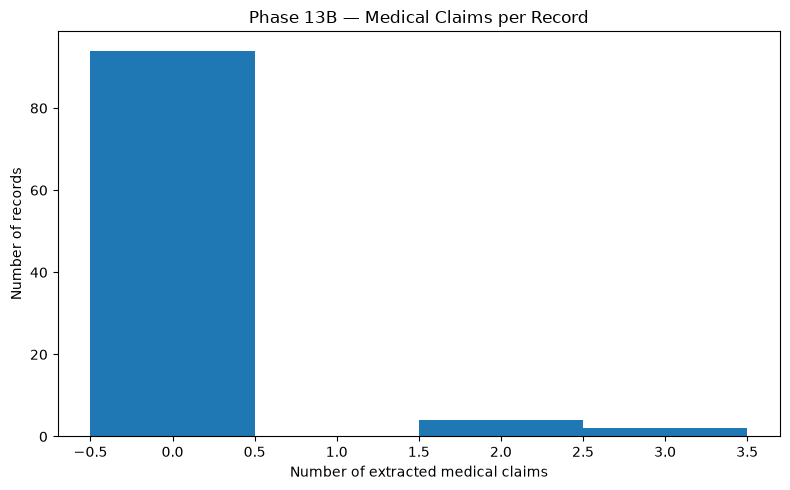

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase13b\visualizations\phase13b_claims_per_record.png


In [28]:
# ============================================================
# PHASE 13B — CELL 28
# Claims per record plot
# ============================================================

plt.figure(figsize=(8, 5))

max_claims = int(
    record_claim_counts["num_claims"].max()
)

plt.hist(
    record_claim_counts["num_claims"],
    bins=range(
        0,
        max_claims + 2
    ),
    align="left"
)

plt.xlabel(
    "Number of extracted medical claims"
)

plt.ylabel(
    "Number of records"
)

plt.title(
    "Phase 13B — Medical Claims per Record"
)

plt.tight_layout()

CLAIMS_PLOT = (
    VIS_DIR /
    "phase13b_claims_per_record.png"
)

plt.savefig(
    CLAIMS_PLOT,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    CLAIMS_PLOT
)

In [29]:
# ============================================================
# PHASE 13B — CELL 29
# Phase 14 evidence retrieval input
# ============================================================

PHASE14_INPUT = (
    MANIFEST_DIR /
    "phase14_evidence_retrieval_input.csv"
)

phase14_input = refined_claims[
    [
        "claim_id",
        "record_key",
        "image_path",
        "label",
        "source",
        "phase11_split",
        "claim_text",
        "claim_type",
        "topics",
        "health_terms",
        "quantitative_values",
        "candidate_score"
    ]
].copy()

phase14_input.to_csv(
    PHASE14_INPUT,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Phase 14 input saved:"
)

print(
    PHASE14_INPUT
)

print(
    "Claims:",
    len(phase14_input)
)

print(
    "Records represented:",
    phase14_input["record_key"].nunique()
    if len(phase14_input)
    else 0
)

Phase 14 input saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase14_evidence_retrieval_input.csv
Claims: 14
Records represented: 6


In [30]:
# ============================================================
# PHASE 13B — CELL 30
# Phase 14 JSONL
# ============================================================

PHASE14_JSONL = (
    MANIFEST_DIR /
    "phase14_evidence_retrieval_input.jsonl"
)

with open(
    PHASE14_JSONL,
    "w",
    encoding="utf-8"
) as f:

    for record in phase14_input.to_dict(
        orient="records"
    ):

        f.write(
            json.dumps(
                json_safe(record),
                ensure_ascii=False
            )
            + "\n"
        )

print(
    "Phase 14 JSONL saved:"
)

print(
    PHASE14_JSONL
)

Phase 14 JSONL saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase14_evidence_retrieval_input.jsonl


In [31]:
# ============================================================
# PHASE 13B — CELL 31
# Final quality checks
# ============================================================

print("=" * 80)
print("PHASE 13B FINAL QUALITY CHECK")
print("=" * 80)

# ------------------------------------------------------------
# 1. Basic counts
# ------------------------------------------------------------

print(
    "\nInput records:",
    len(df)
)

print(
    "Final claims:",
    len(refined_claims)
)

print(
    "Records represented:",
    refined_claims["record_key"].nunique()
    if len(refined_claims)
    else 0
)

# ------------------------------------------------------------
# 2. Metadata leakage
# ------------------------------------------------------------

metadata_claims = refined_claims[
    refined_claims["claim_text"]
    .apply(looks_like_metadata)
]

print(
    "\nMetadata-like final claims:",
    len(metadata_claims)
)

# ------------------------------------------------------------
# 3. CTA leakage
# ------------------------------------------------------------

cta_claims = refined_claims[
    refined_claims["claim_text"]
    .apply(looks_like_cta)
]

print(
    "CTA-like final claims:",
    len(cta_claims)
)

# ------------------------------------------------------------
# 4. Product-code leakage
# ------------------------------------------------------------

code_claims = refined_claims[
    refined_claims["claim_text"]
    .apply(looks_like_product_code)
]

print(
    "Product/code-like final claims:",
    len(code_claims)
)

# ------------------------------------------------------------
# 5. Empty claims
# ------------------------------------------------------------

empty_claims = refined_claims[
    refined_claims["claim_text"]
    .fillna("")
    .str.strip()
    .eq("")
]

print(
    "Empty final claims:",
    len(empty_claims)
)

# ------------------------------------------------------------
# 6. Duplicate claims
# ------------------------------------------------------------

duplicate_count = (
    refined_claims
    .duplicated(
        subset=[
            "record_key",
            "normalized_claim"
        ]
    )
    .sum()
)

print(
    "Duplicate final claims:",
    duplicate_count
)

# ------------------------------------------------------------
# 7. Record JSON count
# ------------------------------------------------------------

json_count = len(
    list(
        CLAIMS_DIR.glob(
            "record_*.json"
        )
    )
)

print(
    "Record-level JSON files:",
    json_count
)

print("=" * 80)

if (
    len(metadata_claims) == 0
    and len(cta_claims) == 0
    and len(code_claims) == 0
    and len(empty_claims) == 0
    and duplicate_count == 0
    and json_count == len(df)
):
    print(
        "✓ PHASE 13B QUALITY CHECK PASSED"
    )
else:
    print(
        "⚠ PHASE 13B QUALITY CHECK NEEDS REVIEW"
    )

PHASE 13B FINAL QUALITY CHECK

Input records: 100
Final claims: 14
Records represented: 6

Metadata-like final claims: 0
CTA-like final claims: 0
Product/code-like final claims: 0
Empty final claims: 0
Duplicate final claims: 0
Record-level JSON files: 100
✓ PHASE 13B QUALITY CHECK PASSED


In [32]:
# ============================================================
# PHASE 13B — CELL 32
# Final summary
# ============================================================

summary = {

    "phase":
        "Phase 13B — Refined Medical Claim Extraction",

    "input_records":
        int(len(df)),

    "baseline_claims":
        int(baseline_count),

    "baseline_records_with_claims":
        int(baseline_records),

    "refined_claims":
        int(refined_count),

    "refined_records_with_claims":
        int(refined_records),

    "records_without_claims":
        int(
            len(df)
            - refined_records
        ),

    "metadata_like_final_claims":
        int(len(metadata_claims)),

    "cta_like_final_claims":
        int(len(cta_claims)),

    "product_code_like_final_claims":
        int(len(code_claims)),

    "empty_final_claims":
        int(len(empty_claims)),

    "duplicate_final_claims":
        int(duplicate_count),

    "record_json_files":
        int(json_count),

    "claim_type_distribution":
        claim_type_stats.to_dict(
            orient="records"
        ),

    "claim_manifest":
        str(CLAIM_MANIFEST_PATH),

    "candidate_audit":
        str(CANDIDATE_AUDIT_PATH),

    "phase14_input":
        str(PHASE14_INPUT),

    "phase14_jsonl":
        str(PHASE14_JSONL)
}

SUMMARY_PATH = (
    METRICS_DIR /
    "phase13b_summary.json"
)

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(summary),
        f,
        indent=2,
        ensure_ascii=False
    )

print(
    json.dumps(
        json_safe(summary),
        indent=2,
        ensure_ascii=False
    )
)

{
  "phase": "Phase 13B — Refined Medical Claim Extraction",
  "input_records": 100,
  "baseline_claims": 12,
  "baseline_records_with_claims": 10,
  "refined_claims": 14,
  "refined_records_with_claims": 6,
  "records_without_claims": 94,
  "metadata_like_final_claims": 0,
  "cta_like_final_claims": 0,
  "product_code_like_final_claims": 0,
  "empty_final_claims": 0,
  "duplicate_final_claims": 0,
  "record_json_files": 100,
  "claim_type_distribution": [
    {
      "claim_type": "quantitative",
      "count": 10
    },
    {
      "claim_type": "unknown",
      "count": 2
    },
    {
      "claim_type": "general_health",
      "count": 2
    }
  ],
  "claim_manifest": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase13b\\manifests\\phase13b_claims_manifest.csv",
  "candidate_audit": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase13b\\manifests\\phase13b_candidate_audit.csv",
  "phase14_input": "d:\\downloads\\misleading-health-infograph

In [33]:
# ============================================================
# PHASE 13B — CELL 33
# Final report
# ============================================================

REPORT_PATH = (
    REPORTS_DIR /
    "phase13b_report.txt"
)

refined_record_count = (
    refined_claims["record_key"].nunique()
    if len(refined_claims)
    else 0
)

report = f"""
PHASE 13B — REFINED MEDICAL CLAIM EXTRACTION
============================================================

Input records:
{len(df)}

Baseline Phase 13 claims:
{baseline_count}

Baseline records with claims:
{baseline_records}

Phase 13B refined claims:
{refined_count}

Phase 13B records with claims:
{refined_record_count}

Records without claims:
{len(df) - refined_record_count}

Claim type distribution:
{claim_type_stats.to_string(index=False)}

Quality checks:
Metadata-like claims: {len(metadata_claims)}
CTA-like claims: {len(cta_claims)}
Product/code-like claims: {len(code_claims)}
Empty claims: {len(empty_claims)}
Duplicate claims: {duplicate_count}

Record-level JSON files:
{json_count}

Artifacts:
{CLAIM_MANIFEST_PATH}
{CANDIDATE_AUDIT_PATH}
{CLAIMS_JSONL_PATH}
{PHASE14_INPUT}
{PHASE14_JSONL}
{SUMMARY_PATH}

Phase 13B extraction completed.
"""

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        report.strip()
    )

print(
    "Report saved:"
)

print(
    REPORT_PATH
)

Report saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase13b\reports\phase13b_report.txt


In [34]:
# ============================================================
# PHASE 13B — CELL 34
# Final artifact check
# ============================================================

expected_files = [

    CLAIM_MANIFEST_PATH,

    CANDIDATE_AUDIT_PATH,

    CLAIMS_JSONL_PATH,

    SOURCE_STATS_PATH,

    LABEL_STATS_PATH,

    TYPE_STATS_PATH,

    COMPARISON_PATH,

    CLAIMS_PLOT,

    PHASE14_INPUT,

    PHASE14_JSONL,

    SUMMARY_PATH,

    REPORT_PATH
]

print("=" * 80)
print("PHASE 13B ARTIFACT CHECK")
print("=" * 80)

all_exist = True

for path in expected_files:

    exists = Path(path).exists()

    print(
        f"{'✓' if exists else '✗'} {path}"
    )

    if not exists:
        all_exist = False

print(
    "\nRecord-level JSON files:",
    json_count
)

print(
    "Input records:",
    len(df)
)

print("=" * 80)

if all_exist and json_count == len(df):

    print(
        "✓ PHASE 13B COMPLETED CORRECTLY"
    )

else:

    print(
        "✗ PHASE 13B ARTIFACT CHECK FAILED"
    )

PHASE 13B ARTIFACT CHECK
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase13b_claims_manifest.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase13b_candidate_audit.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase13b_claims.jsonl
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\metrics\source_wise_claim_stats.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\metrics\label_wise_claim_stats.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\metrics\claim_type_stats.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\metrics\phase13_vs_phase13b_comparison.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\visualizations\phase13b_claims_per_record.png
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13b\manifests\phase14_evidence_r